In [ ]:
# all vs 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [17]:
c0 = pd.read_csv('../../clusters/ALL.CG.vs.cluster0.analysis.txt', sep = ' ', header = None)
c0

,0,1,2,3,4,5,6,7
0,AT1G01010_chr1,3631,5899,0,0,9,0.459544,0.4266537778\tneither\t0\t0\tNA\tNA
1,AT1G01020_chr1,6788,9130,5,0,5,0.467350,0.5757958\thyper\t0.5\t0\tsig04\tNA
2,AT1G01030_chr1,11649,13714,0,0,1,0.000000,0\tneither\t0\t0\tNA\tNA
3,AT1G01040_chr1,23121,31227,18,36,413,0.830033,0.8163723925\thypo\t0.0385439\t0.0770878\tNA\t...
4,AT1G01050_chr1,31170,33171,0,1,20,0.620767,0.6082230476\thypo\t0\t0.047619\tNA\tNA
...,...,...,...,...,...,...,...,...
29564,ATMG09730_chrMt,181268,181347,0,0,1,0.000000,0\tneither\t0\t0\tNA\tNA
29565,ATMG09740_chrMt,191954,192025,0,0,3,0.545800,0.5170756667\tneither\t0\t0\tNA\tNA
29566,ATMG09950_chrMt,333651,333725,0,2,2,0.867100,0.7413305\thypo\t0\t0.5\tsig04\tNA
29567,ATMG09960_chrMt,347266,347348,8,0,15,0.597187,0.6795955217\thyper\t0.347826\t0\tNA\tNA


In [11]:
import pandas as pd
import re

def load_mixed_delimiter_file(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()
    
    data = []
    for line in lines:
        if '\t' in line:
            row = line.strip().split('\t')
        else:
            # Use regular expression to split by multiple spaces
            row = re.split(r'\s+', line.strip())
        data.append(row)
    
    # Determine the maximum number of columns
    max_cols = max(len(row) for row in data)
    
    # Pad rows with fewer columns with empty strings
    for row in data:
        while len(row) < max_cols:
            row.append('')
    
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    return df

# Example usage
filepath = '../../clusters/ALL.CG.vs.cluster0.analysis.txt'
df = load_mixed_delimiter_file(filepath)
df


,0,1,2,3,4,5
0,AT1G01010_chr1 3631 5899 0 0 9 0.4595444444 0....,neither,0,0,NA,NA
1,AT1G01020_chr1 6788 9130 5 0 5 0.46735 0.5757958,hyper,0.5,0,sig04,NA
2,AT1G01030_chr1 11649 13714 0 0 1 0 0,neither,0,0,NA,NA
3,AT1G01040_chr1 23121 31227 18 36 413 0.8300327...,hypo,0.0385439,0.0770878,NA,sigcov
4,AT1G01050_chr1 31170 33171 0 1 20 0.6207666667...,hypo,0,0.047619,NA,NA
...,...,...,...,...,...,...
29564,ATMG09730_chrMt 181268 181347 0 0 1 0 0,neither,0,0,NA,NA
29565,ATMG09740_chrMt 191954 192025 0 0 3 0.5458 0.5...,neither,0,0,NA,NA
29566,ATMG09950_chrMt 333651 333725 0 2 2 0.8671 0.7...,hypo,0,0.5,sig04,NA
29567,ATMG09960_chrMt 347266 347348 8 0 15 0.5971869...,hyper,0.347826,0,NA,NA


In [16]:
import pandas as pd
import re

def load_mixed_delimiter_file(filepath):
    with open(filepath, 'r') as file:
        lines = file.readlines()
    
    data = []
    for line in lines:
        # First split by spaces
        space_split = re.split(r'\s+', line.strip())
        
        # Further split each field by tabs if they contain tabs
        row = []
        for field in space_split:
            if '\t' in field:
                row.extend(field.split('\t'))
            else:
                row.append(field)
        
        data.append(row)
    
    # Determine the maximum number of columns
    max_cols = max(len(row) for row in data)
    
    # Pad rows with fewer columns with empty strings
    for row in data:
        while len(row) < max_cols:
            row.append('')
    
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    return df

# Example usage
df = load_mixed_delimiter_file(filepath)
df


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,AT1G01010_chr1,3631,5899,0,0,9,0.4595444444,0.4266537778,neither,0,0,NA,NA
1,AT1G01020_chr1,6788,9130,5,0,5,0.46735,0.5757958,hyper,0.5,0,sig04,NA
2,AT1G01030_chr1,11649,13714,0,0,1,0,0,neither,0,0,NA,NA
3,AT1G01040_chr1,23121,31227,18,36,413,0.8300327623,0.8163723925,hypo,0.0385439,0.0770878,NA,sigcov
4,AT1G01050_chr1,31170,33171,0,1,20,0.6207666667,0.6082230476,hypo,0,0.047619,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29564,ATMG09730_chrMt,181268,181347,0,0,1,0,0,neither,0,0,NA,NA
29565,ATMG09740_chrMt,191954,192025,0,0,3,0.5458,0.5170756667,neither,0,0,NA,NA
29566,ATMG09950_chrMt,333651,333725,0,2,2,0.8671,0.7413305,hypo,0,0.5,sig04,NA
29567,ATMG09960_chrMt,347266,347348,8,0,15,0.5971869565,0.6795955217,hyper,0.347826,0,NA,NA


In [21]:
import pandas as pd

def load_mixed_delimiter_file(filepath):
    column_names = [
        "Gene_chr", "start", "end", "Hyper", "Hypo", "Neither",
        "All_meth_avg", "Clst_meth_avg", "state", "PC_hyper",
        "PC_Hypo", "PC_40_sig", "above9_sig"
    ]
    df = pd.read_csv(filepath, sep=r'\s+', engine='python', header=None, names=column_names)
    return df

df = load_mixed_delimiter_file(filepath).set_index('Gene_chr')
df


,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig
Gene_chr,,,,,,,,,,,,
AT1G01010_chr1,3631,5899,0,0,9,0.459544,0.426654,neither,0.000000,0.000000,NaN,NaN
AT1G01020_chr1,6788,9130,5,0,5,0.467350,0.575796,hyper,0.500000,0.000000,sig04,NaN
AT1G01030_chr1,11649,13714,0,0,1,0.000000,0.000000,neither,0.000000,0.000000,NaN,NaN
AT1G01040_chr1,23121,31227,18,36,413,0.830033,0.816372,hypo,0.038544,0.077088,NaN,sigcov
AT1G01050_chr1,31170,33171,0,1,20,0.620767,0.608223,hypo,0.000000,0.047619,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG09730_chrMt,181268,181347,0,0,1,0.000000,0.000000,neither,0.000000,0.000000,NaN,NaN
ATMG09740_chrMt,191954,192025,0,0,3,0.545800,0.517076,neither,0.000000,0.000000,NaN,NaN
ATMG09950_chrMt,333651,333725,0,2,2,0.867100,0.741331,hypo,0.000000,0.500000,sig04,NaN


In [44]:
36/413

0.08716707021791767

In [38]:
df = df[~((df["All_meth_avg"] == 0) & (df["Clst_meth_avg"] == 0))]

In [45]:
df

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig
Gene_chr,,,,,,,,,,,,
AT1G01010_chr1,3631,5899,0,0,9,0.459544,0.426654,neither,0.000000,0.000000,NaN,NaN
AT1G01020_chr1,6788,9130,5,0,5,0.467350,0.575796,hyper,0.500000,0.000000,sig04,NaN
AT1G01040_chr1,23121,31227,18,36,413,0.830033,0.816372,hypo,0.038544,0.077088,NaN,sigcov
AT1G01050_chr1,31170,33171,0,1,20,0.620767,0.608223,hypo,0.000000,0.047619,NaN,NaN
AT1G01060_chr1,33365,37871,1,7,31,0.734118,0.701700,hypo,0.025641,0.179487,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG01410_chrMt,366086,366700,4,4,57,0.619303,0.636833,neither,0.061539,0.061539,NaN,NaN
ATMG09740_chrMt,191954,192025,0,0,3,0.545800,0.517076,neither,0.000000,0.000000,NaN,NaN
ATMG09950_chrMt,333651,333725,0,2,2,0.867100,0.741331,hypo,0.000000,0.500000,sig04,NaN


In [48]:
7/(1+7+31)

0.1794871794871795

<AxesSubplot:xlabel='All_meth_avg', ylabel='Count'>

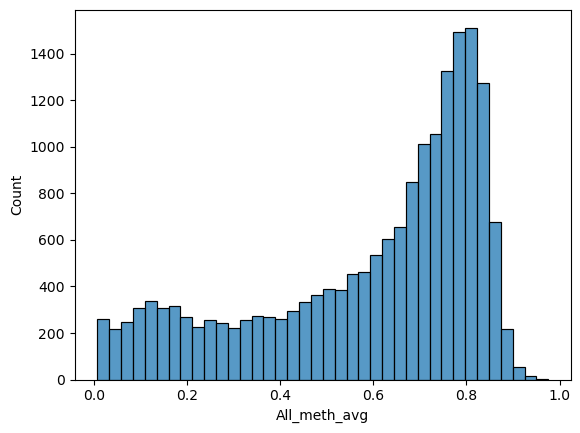

In [39]:
sns.histplot(df['All_meth_avg'])

<AxesSubplot:xlabel='Clst_meth_avg', ylabel='Count'>

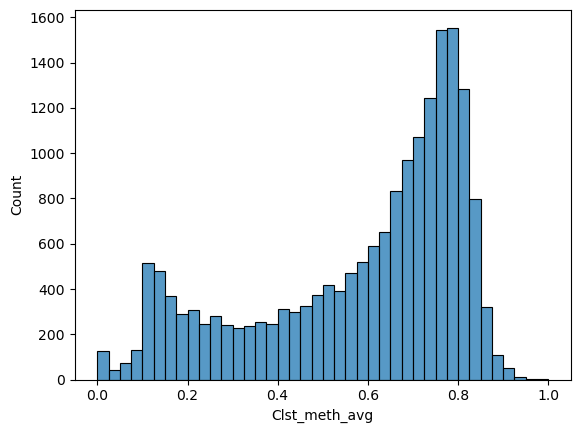

In [40]:

sns.histplot(df['Clst_meth_avg'])

<AxesSubplot:xlabel='PC_hyper', ylabel='Count'>

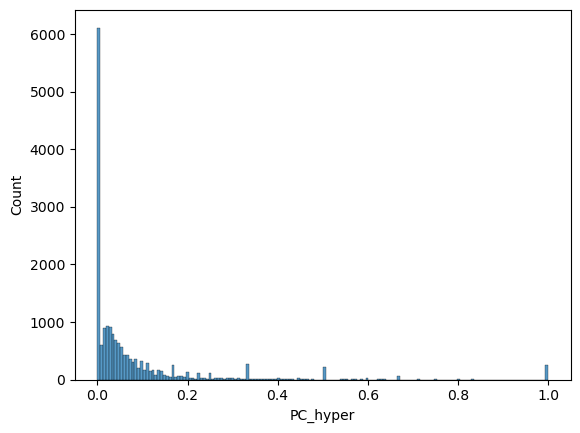

In [41]:
sns.histplot(df['PC_hyper'])

In [68]:
df['PC_Hypo']

0        0.000000
1        0.166667
2        0.000000
3        0.132701
4        0.173913
           ...   
29564    0.000000
29565    0.000000
29566    0.000000
29567    0.260870
29568    0.000000
Name: PC_Hypo, Length: 29569, dtype: float64

In [71]:
temp = df[df['PC_Hypo']!=0]

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

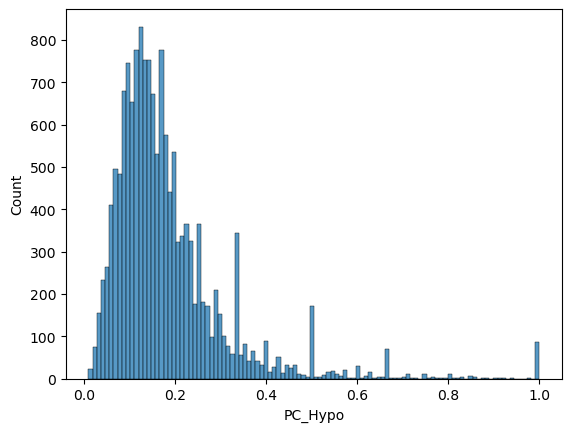

In [77]:
sns.histplot(temp['PC_Hypo'])

In [49]:
#attempt to load all df 

In [50]:
import pandas as pd
import glob

# Define the path pattern
path_pattern = "../../clusters/ALL.CG.vs.cluster*.analysis.txt"

# Find all files matching the pattern
file_list = glob.glob(path_pattern)

# Define column names
column_names = [
    "Gene_chr", "start", "end", "Hyper", "Hypo", "Neither",
    "All_meth_avg", "Clst_meth_avg", "state", "PC_hyper",
    "PC_Hypo", "PC_40_sig", "above9_sig"
]

# Initialize an empty list to hold DataFrames
dfs = []

# Read each file into a DataFrame and append to the list
for file in file_list:
    df = pd.read_csv(file, sep=r'\s+', engine='python', header=None, names=column_names)
    dfs.append(df)

# Concatenate all DataFrames
combined_df = pd.concat(dfs)

# Set Gene_chr as the index
combined_df.set_index("Gene_chr", inplace=True)

# Example: Display the combined DataFrame
combined_df

# Optionally, save the combined DataFrame to a CSV file
combined_df.to_csv('./data/ALL.CG.vs.ALL.clusters.analysis.txt')


,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig
Gene_chr,,,,,,,,,,,,
AT1G01010_chr1,3631,5899,3,4,4,0.376573,0.309256,hypo,0.272727,0.363636,NaN,NaN
AT1G01020_chr1,6788,9130,3,6,2,0.425918,0.356241,hypo,0.272727,0.545455,sig04,NaN
AT1G01030_chr1,11649,13714,1,0,0,0.010100,0.125000,hyper,1.000000,0.000000,sig04,NaN
AT1G01040_chr1,23121,31227,94,33,329,0.829234,0.871306,hyper,0.206140,0.072368,NaN,sigcov
AT1G01050_chr1,31170,33171,3,8,12,0.568135,0.522568,hypo,0.130435,0.347826,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG09730_chrMt,181268,181347,0,0,1,0.000000,0.000000,neither,0.000000,0.000000,NaN,NaN
ATMG09740_chrMt,191954,192025,0,0,3,0.545800,0.629386,neither,0.000000,0.000000,NaN,NaN
ATMG09950_chrMt,333651,333725,1,0,1,0.804650,1.000000,hyper,0.500000,0.000000,sig04,NaN


In [52]:
combined_df.to_csv('./data/ALL.CG.vs.ALL.clusters.analysis.csv')

In [54]:
filtered_df = combined_df[~((combined_df["All_meth_avg"] == 0) & (combined_df["Clst_meth_avg"] == 0))]

In [55]:
filtered_df

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig
Gene_chr,,,,,,,,,,,,
AT1G01010_chr1,3631,5899,3,4,4,0.376573,0.309256,hypo,0.272727,0.363636,NaN,NaN
AT1G01020_chr1,6788,9130,3,6,2,0.425918,0.356241,hypo,0.272727,0.545455,sig04,NaN
AT1G01030_chr1,11649,13714,1,0,0,0.010100,0.125000,hyper,1.000000,0.000000,sig04,NaN
AT1G01040_chr1,23121,31227,94,33,329,0.829234,0.871306,hyper,0.206140,0.072368,NaN,sigcov
AT1G01050_chr1,31170,33171,3,8,12,0.568135,0.522568,hypo,0.130435,0.347826,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG01410_chrMt,366086,366700,36,6,23,0.619303,0.716209,hyper,0.553846,0.092308,sig04,sigcov
ATMG09740_chrMt,191954,192025,0,0,3,0.545800,0.629386,neither,0.000000,0.000000,NaN,NaN
ATMG09950_chrMt,333651,333725,1,0,1,0.804650,1.000000,hyper,0.500000,0.000000,sig04,NaN


In [56]:
filtered_df =  filtered_df[~filtered_df.index.str.startswith(('ATM', 'ATC'))]

In [57]:
filtered_df

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig
Gene_chr,,,,,,,,,,,,
AT1G01010_chr1,3631,5899,3,4,4,0.376573,0.309256,hypo,0.272727,0.363636,NaN,NaN
AT1G01020_chr1,6788,9130,3,6,2,0.425918,0.356241,hypo,0.272727,0.545455,sig04,NaN
AT1G01030_chr1,11649,13714,1,0,0,0.010100,0.125000,hyper,1.000000,0.000000,sig04,NaN
AT1G01040_chr1,23121,31227,94,33,329,0.829234,0.871306,hyper,0.206140,0.072368,NaN,sigcov
AT1G01050_chr1,31170,33171,3,8,12,0.568135,0.522568,hypo,0.130435,0.347826,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600_chr5,26959533,26960399,1,0,0,0.014600,0.125000,hyper,1.000000,0.000000,sig04,NaN
AT5G67610_chr5,26960904,26963736,10,9,19,0.789876,0.801582,hyper,0.263158,0.236842,NaN,sigcov
AT5G67620_chr5,26964551,26966010,6,0,3,0.017011,0.149912,hyper,0.666667,0.000000,sig04,NaN


In [58]:
filtered_df.to_csv('./data/filtered_ALL.CG.vs.ALL.clusters.analysis.csv')

In [66]:
import pandas as pd
import glob
import re

# Define the path pattern
path_pattern = "../../clusters/ALL.CG.vs.cluster*.analysis.txt"

# Find all files matching the pattern
file_list = glob.glob(path_pattern)

# Define column names
column_names = [
    "Gene_chr", "start", "end", "Hyper", "Hypo", "Neither",
    "All_meth_avg", "Clst_meth_avg", "state", "PC_hyper",
    "PC_Hypo", "PC_40_sig", "above9_sig"
]

# Initialize an empty list to hold DataFrames
dfs = []

# Read each file into a DataFrame, add the cluster column, and append to the list
for file in file_list:
    # Extract cluster number using regular expression
    cluster_number = int(re.search(r'cluster(\d+)', file).group(1))
    
    # Read the file
    df = pd.read_csv(file, sep=r'\s+', engine='python', header=None, names=column_names)
    
    # Add the cluster column
    df['cluster'] = cluster_number
    
    # Append to the list
    dfs.append(df)

# Concatenate all DataFrames
combined_df = pd.concat(dfs)

# Set Gene_chr as the index
combined_df.set_index("Gene_chr", inplace=True)

# Remove rows where the gene name starts with ATM or ATC
combined_df = combined_df[~combined_df.index.str.startswith(('ATM', 'ATC'))]

# Example: Display the combined DataFrame
# print(combined_df)

combined_df
# # Optionally, save the combined DataFrame to a CSV file
# combined_df.to_csv('../../clusters/combined_analysis_filtered_with_clusters.csv')


,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig,cluster
Gene_chr,,,,,,,,,,,,,
AT1G01010_chr1,3631,5899,3,4,4,0.376573,0.309256,hypo,0.272727,0.363636,NaN,NaN,7
AT1G01020_chr1,6788,9130,3,6,2,0.425918,0.356241,hypo,0.272727,0.545455,sig04,NaN,7
AT1G01030_chr1,11649,13714,1,0,0,0.010100,0.125000,hyper,1.000000,0.000000,sig04,NaN,7
AT1G01040_chr1,23121,31227,94,33,329,0.829234,0.871306,hyper,0.206140,0.072368,NaN,sigcov,7
AT1G01050_chr1,31170,33171,3,8,12,0.568135,0.522568,hypo,0.130435,0.347826,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600_chr5,26959533,26960399,1,0,0,0.014600,0.125000,hyper,1.000000,0.000000,sig04,NaN,8
AT5G67610_chr5,26960904,26963736,10,9,19,0.789876,0.801582,hyper,0.263158,0.236842,NaN,sigcov,8
AT5G67620_chr5,26964551,26966010,6,0,3,0.017011,0.149912,hyper,0.666667,0.000000,sig04,NaN,8


In [67]:
combined_df[combined_df['cluster']==0]

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig,cluster
Gene_chr,,,,,,,,,,,,,
AT1G01010_chr1,3631,5899,0,0,9,0.459544,0.426654,neither,0.000000,0.000000,NaN,NaN,0
AT1G01020_chr1,6788,9130,5,0,5,0.467350,0.575796,hyper,0.500000,0.000000,sig04,NaN,0
AT1G01030_chr1,11649,13714,0,0,1,0.000000,0.000000,neither,0.000000,0.000000,NaN,NaN,0
AT1G01040_chr1,23121,31227,18,36,413,0.830033,0.816372,hypo,0.038544,0.077088,NaN,sigcov,0
AT1G01050_chr1,31170,33171,0,1,20,0.620767,0.608223,hypo,0.000000,0.047619,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67600_chr5,26959533,26960399,0,0,1,0.000000,0.000000,neither,0.000000,0.000000,NaN,NaN,0
AT5G67610_chr5,26960904,26963736,3,0,33,0.833442,0.855341,hyper,0.083333,0.000000,NaN,NaN,0
AT5G67620_chr5,26964551,26966010,0,0,1,0.000000,0.000000,neither,0.000000,0.000000,NaN,NaN,0


In [73]:
combined_df.to_csv('./data/filtered_clusters_ALL.CG.vs.ALL.clusters.analysis.csv')

In [82]:
sig_df = combined_df.loc[(combined_df['PC_40_sig']=='sig04')& (combined_df['above9_sig']=='sigcov') ,:]
sig_df

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig,cluster
Gene_chr,,,,,,,,,,,,,
AT1G01060_chr1,33365,37871,18,4,17,0.731990,0.832560,hyper,0.461538,0.102564,sig04,sigcov,7
AT1G01220_chr1,91342,95681,14,43,48,0.786261,0.695158,hypo,0.133333,0.409524,sig04,sigcov,7
AT1G01340_chr1,132270,135924,34,7,39,0.496309,0.555956,hyper,0.425000,0.087500,sig04,sigcov,7
AT1G01530_chr1,192634,193670,17,3,17,0.817327,0.930675,hyper,0.459459,0.081081,sig04,sigcov,7
AT1G01540_chr1,195645,198787,31,13,33,0.531369,0.572159,hyper,0.402597,0.168831,sig04,sigcov,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G67280_chr5,26842114,26845294,10,0,1,0.008355,0.144297,hyper,0.909091,0.000000,sig04,sigcov,8
AT5G67340_chr5,26864395,26867847,12,51,32,0.448654,0.344409,hypo,0.126316,0.536842,sig04,sigcov,8
AT5G67440_chr5,26912707,26916453,11,9,7,0.368844,0.384059,hyper,0.407407,0.333333,sig04,sigcov,8


<AxesSubplot:xlabel='PC_hyper', ylabel='Count'>

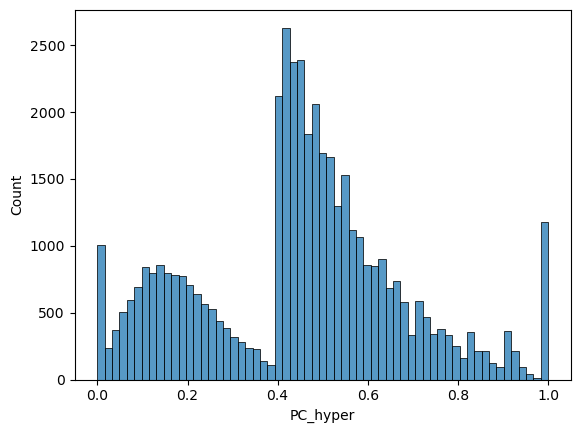

In [83]:
sns.histplot(sig_df['PC_hyper'])

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

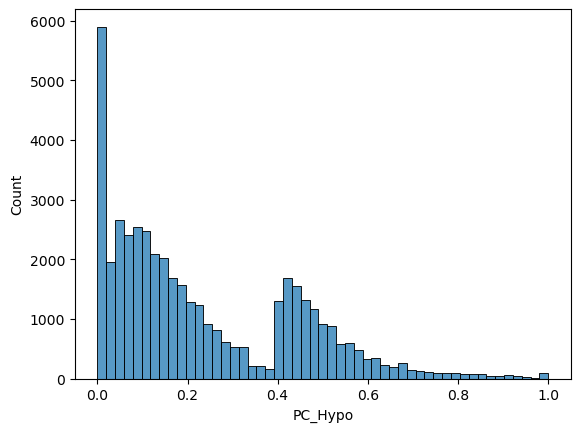

In [84]:
sns.histplot(sig_df['PC_Hypo'])

In [86]:
temp = sig_df[sig_df['cluster']==0]
temp

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig,cluster
Gene_chr,,,,,,,,,,,,,
AT1G02110_chr1,392831,395528,52,2,37,0.560459,0.672121,hyper,0.571429,0.021978,sig04,sigcov,0
AT1G03140_chr1,754261,756303,0,10,0,0.420000,0.213137,hypo,0.000000,1.000000,sig04,sigcov,0
AT1G06730_chr1,2067509,2070455,1,22,22,0.430302,0.326141,hypo,0.022222,0.488889,sig04,sigcov,0
AT1G09160_chr1,2952597,2955745,1,36,12,0.389000,0.254087,hypo,0.020408,0.734694,sig04,sigcov,0
AT1G09995_chr1,3262222,3263642,10,0,0,0.033710,0.293484,hyper,1.000000,0.000000,sig04,sigcov,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G56540_chr5,22893151,22893651,15,0,14,0.479231,0.582579,hyper,0.517241,0.000000,sig04,sigcov,0
AT5G58300_chr5,23571835,23575084,1,15,19,0.646906,0.567652,hypo,0.028571,0.428571,sig04,sigcov,0
AT5G58570_chr5,23672695,23673287,0,14,10,0.361371,0.260633,hypo,0.000000,0.583333,sig04,sigcov,0


<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

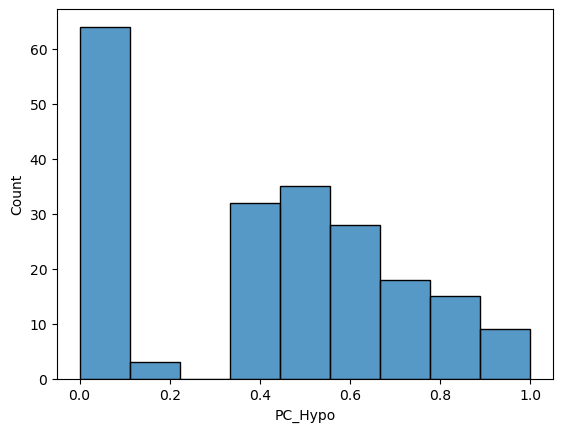

In [125]:
# sns.histplot(temp['PC_hyper'])
sns.histplot(temp['PC_Hypo'])

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

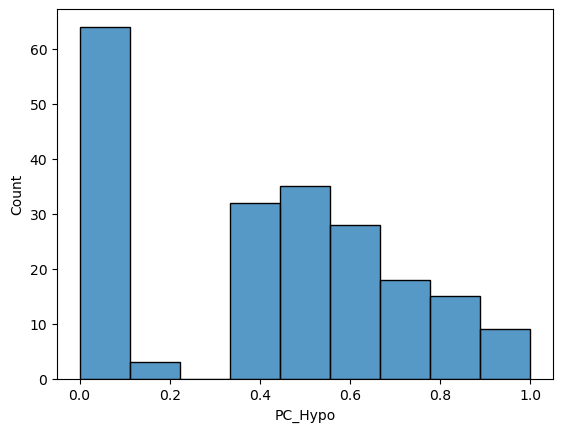

<AxesSubplot:xlabel='All_meth_avg', ylabel='Count'>

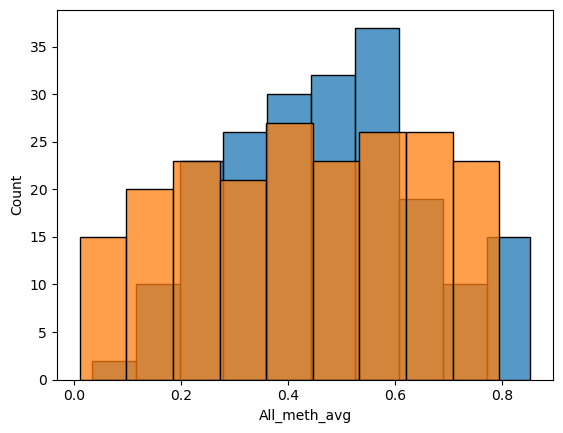

In [103]:
sns.histplot(temp['All_meth_avg'])
sns.histplot(temp['Clst_meth_avg'])

<AxesSubplot:xlabel='Clst_meth_avg', ylabel='Count'>

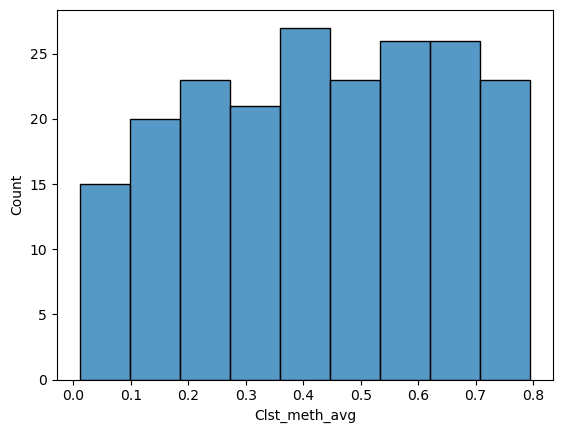

In [112]:
c2 = sig_df[sig_df['cluster']==2]
c2

13

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

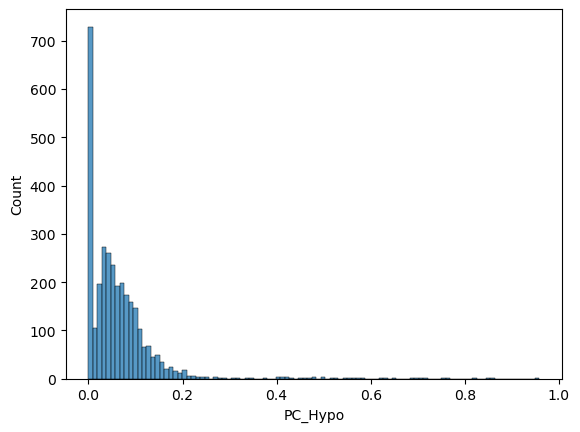

In [126]:
# sns.histplot(c2['PC_hyper'])
sns.histplot(c2['PC_Hypo'])

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

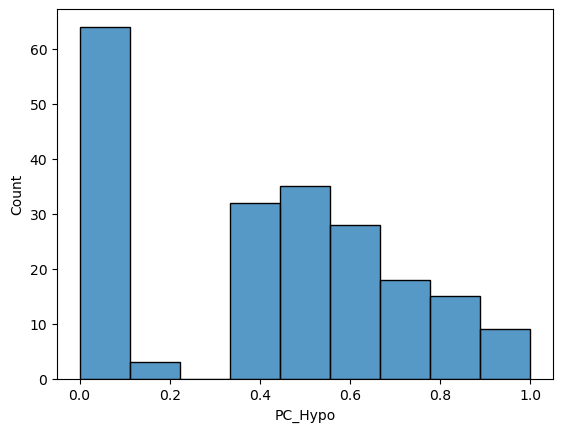

In [93]:
sns.histplot(temp['PC_Hypo'])

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig,cluster
Gene_chr,,,,,,,,,,,,,
AT1G01060_chr1,33365,37871,19,3,21,0.664700,0.719101,hyper,0.441860,0.069767,sig04,sigcov,2
AT1G01150_chr1,69911,72138,20,0,19,0.515115,0.617826,hyper,0.512821,0.000000,sig04,sigcov,2
AT1G01230_chr1,97412,99240,15,1,7,0.409765,0.634952,hyper,0.652174,0.043478,sig04,sigcov,2
AT1G01410_chr1,153113,154198,10,0,0,0.212730,0.396037,hyper,1.000000,0.000000,sig04,sigcov,2
AT1G01660_chr1,239841,242703,36,3,38,0.656365,0.750651,hyper,0.467532,0.038961,sig04,sigcov,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G66880_chr5,26710302,26712971,12,2,10,0.589571,0.666077,hyper,0.500000,0.083333,sig04,sigcov,2
AT5G67030_chr5,26753469,26757402,28,2,33,0.461510,0.547098,hyper,0.444444,0.031746,sig04,sigcov,2
AT5G67090_chr5,26773939,26776391,28,3,20,0.355822,0.446140,hyper,0.549020,0.058824,sig04,sigcov,2


<AxesSubplot:xlabel='All_meth_avg', ylabel='Count'>

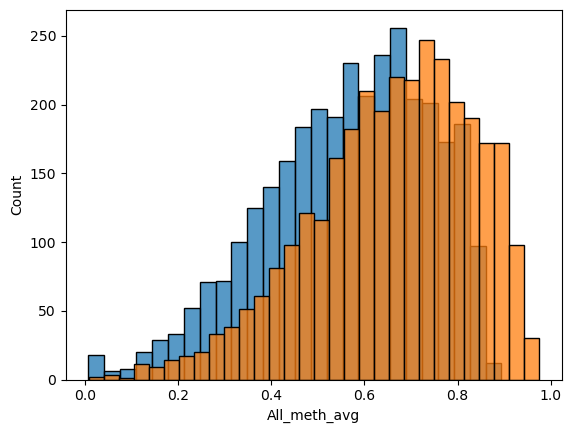

In [100]:
sns.histplot(c2['All_meth_avg'])
sns.histplot(c2['Clst_meth_avg'])

<AxesSubplot:xlabel='Clst_meth_avg', ylabel='Count'>

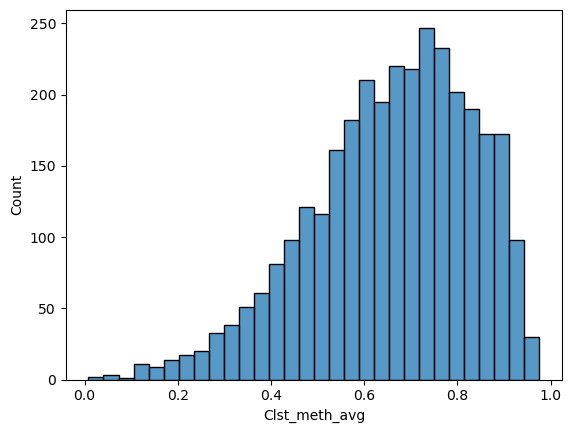

In [105]:
sns.histplot(c2['Clst_meth_avg'])

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

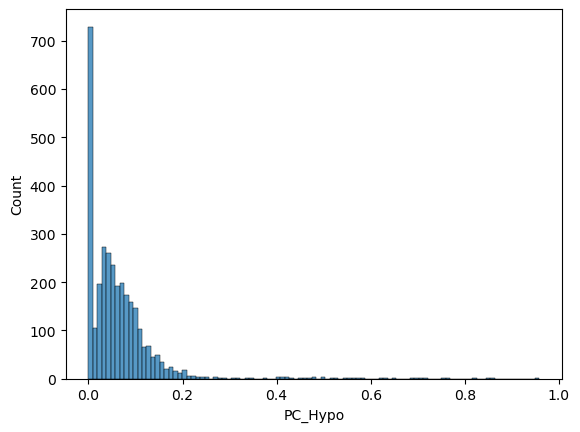

In [106]:
sns.histplot(c2['PC_Hypo'])

In [113]:
c2_hypo = c2[c2['state']=='hypo']
c2_hypo.shape[0]

49

<AxesSubplot:xlabel='All_meth_avg', ylabel='Count'>

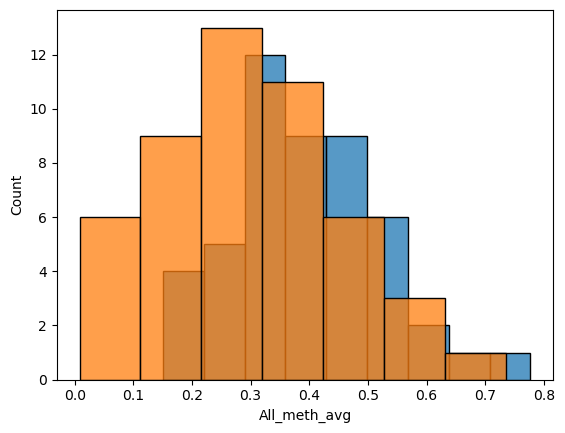

In [110]:
sns.histplot(c2_hypo['All_meth_avg'])
sns.histplot(c2_hypo['Clst_meth_avg'])

In [114]:
c11_hypo = sig_df[(sig_df['cluster']==0) & (sig_df['state']=='hypo')]
c11_hypo

,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig,cluster
Gene_chr,,,,,,,,,,,,,
AT1G03140_chr1,754261,756303,0,10,0,0.420000,0.213137,hypo,0.000000,1.000000,sig04,sigcov,0
AT1G06730_chr1,2067509,2070455,1,22,22,0.430302,0.326141,hypo,0.022222,0.488889,sig04,sigcov,0
AT1G09160_chr1,2952597,2955745,1,36,12,0.389000,0.254087,hypo,0.020408,0.734694,sig04,sigcov,0
AT1G11860_chr1,4001113,4003748,0,35,4,0.313679,0.146523,hypo,0.000000,0.897436,sig04,sigcov,0
AT1G14710_chr1,5061694,5065303,2,45,55,0.545753,0.454529,hypo,0.019608,0.441176,sig04,sigcov,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G56000_chr5,22677338,22680152,1,38,23,0.605065,0.487787,hypo,0.016129,0.612903,sig04,sigcov,0
AT5G58300_chr5,23571835,23575084,1,15,19,0.646906,0.567652,hypo,0.028571,0.428571,sig04,sigcov,0
AT5G58570_chr5,23672695,23673287,0,14,10,0.361371,0.260633,hypo,0.000000,0.583333,sig04,sigcov,0


<AxesSubplot:xlabel='All_meth_avg', ylabel='Count'>

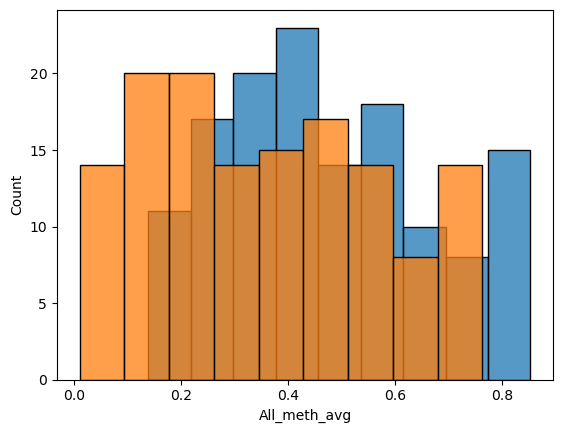

In [115]:
sns.histplot(c11_hypo['All_meth_avg'])
sns.histplot(c11_hypo['Clst_meth_avg'])

<AxesSubplot:xlabel='PC_hyper', ylabel='Count'>

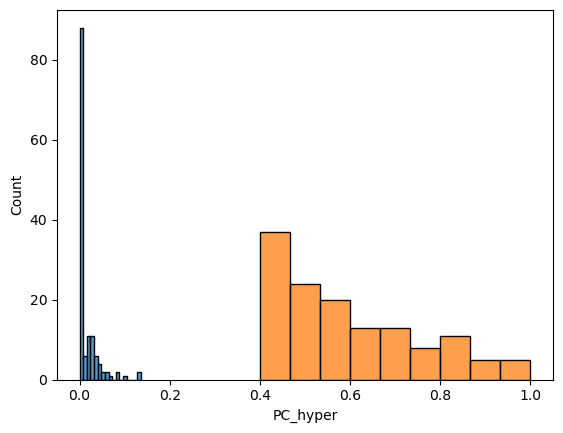

In [116]:
sns.histplot(c11_hypo['PC_hyper'])
sns.histplot(c11_hypo['PC_Hypo'])

In [119]:
c2_hypo


,start,end,Hyper,Hypo,Neither,All_meth_avg,Clst_meth_avg,state,PC_hyper,PC_Hypo,PC_40_sig,above9_sig,cluster
Gene_chr,,,,,,,,,,,,,
AT1G07380_chr1,2264634,2269121,8,31,34,0.446979,0.392655,hypo,0.109589,0.424658,sig04,sigcov,2
AT1G07930_chr1,2458184,2460817,5,10,7,0.615782,0.581886,hypo,0.227273,0.454545,sig04,sigcov,2
AT1G09160_chr1,2952597,2955745,3,35,12,0.381548,0.256471,hypo,0.060000,0.700000,sig04,sigcov,2
AT1G22850_chr1,8080482,8082882,5,13,13,0.684552,0.619369,hypo,0.161290,0.419355,sig04,sigcov,2
AT1G47580_chr1,17485576,17486463,0,23,1,0.183413,0.008310,hypo,0.000000,0.958333,sig04,sigcov,2
AT1G52905_chr1,19706047,19706885,15,46,32,0.352246,0.259910,hypo,0.161290,0.494624,sig04,sigcov,2
AT1G70790_chr1,26699321,26702544,1,39,28,0.370813,0.263778,hypo,0.014706,0.573529,sig04,sigcov,2
AT1G77340_chr1,29068343,29070037,1,10,5,0.268137,0.168774,hypo,0.062500,0.625000,sig04,sigcov,2
AT1G78180_chr1,29416837,29418561,0,10,8,0.304672,0.217550,hypo,0.000000,0.555556,sig04,sigcov,2


In [121]:
c2_hypo_diff = c2_hypo['All_meth_avg'] - c2_hypo['Clst_meth_avg']
c2_hypo_diff

Gene_chr
AT1G07380_chr1    0.054324
AT1G07930_chr1    0.033896
AT1G09160_chr1    0.125077
AT1G22850_chr1    0.065182
AT1G47580_chr1    0.175103
AT1G52905_chr1    0.092336
AT1G70790_chr1    0.107036
AT1G77340_chr1    0.099363
AT1G78180_chr1    0.087122
AT2G05060_chr2    0.056703
AT2G33110_chr2    0.065016
AT2G34430_chr2    0.063711
AT2G37420_chr2    0.021803
AT2G40960_chr2    0.183902
AT2G44200_chr2    0.063843
AT3G03145_chr3    0.120499
AT3G06030_chr3    0.125977
AT3G15570_chr3    0.120499
AT3G21870_chr3    0.087835
AT3G27680_chr3    0.086836
AT3G28220_chr3    0.124294
AT3G44480_chr3    0.037138
AT3G45140_chr3    0.110609
AT3G46670_chr3    0.090956
AT4G00860_chr4    0.079648
AT4G01130_chr4    0.113218
AT4G03280_chr4    0.055558
AT4G05670_chr4    0.071100
AT4G05675_chr4    0.071100
AT4G09000_chr4    0.080760
AT4G17100_chr4    0.114293
AT4G28040_chr4    0.109751
AT4G36925_chr4    0.048473
AT4G37550_chr4    0.066349
AT5G08275_chr5    0.145045
AT5G13310_chr5    0.067077
AT5G15780_chr5    0

<AxesSubplot:ylabel='Count'>

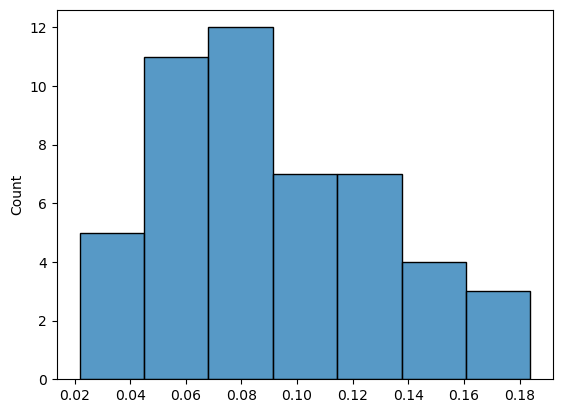

In [122]:
sns.histplot(c2_hypo_diff)

In [123]:
c11_hypo_diff = c11_hypo['All_meth_avg'] - c11_hypo['Clst_meth_avg']
c11_hypo_diff

Gene_chr
AT1G03140_chr1    0.206863
AT1G06730_chr1    0.104161
AT1G09160_chr1    0.134913
AT1G11860_chr1    0.167156
AT1G14710_chr1    0.091224
                    ...   
AT5G56000_chr5    0.117277
AT5G58300_chr5    0.079254
AT5G58570_chr5    0.100738
AT5G61070_chr5    0.106638
AT5G65280_chr5    0.130111
Length: 136, dtype: float64

<AxesSubplot:ylabel='Count'>

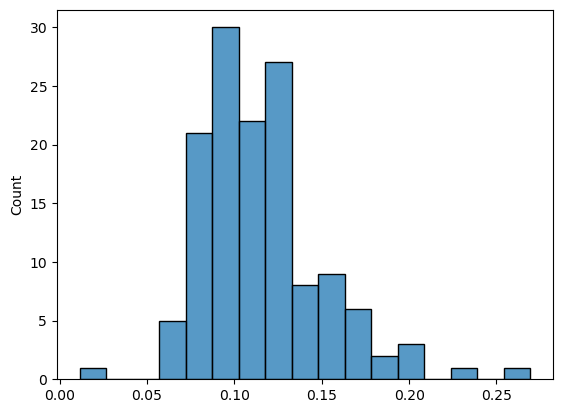

In [124]:
sns.histplot(c11_hypo_diff)

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

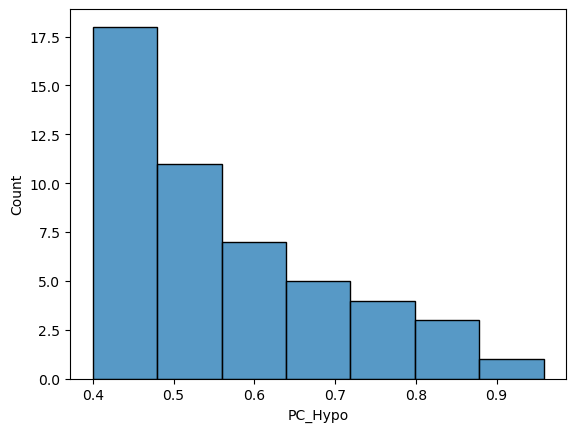

In [129]:
sns.histplot(c2_hypo['PC_Hypo'])

<AxesSubplot:xlabel='PC_Hypo', ylabel='Count'>

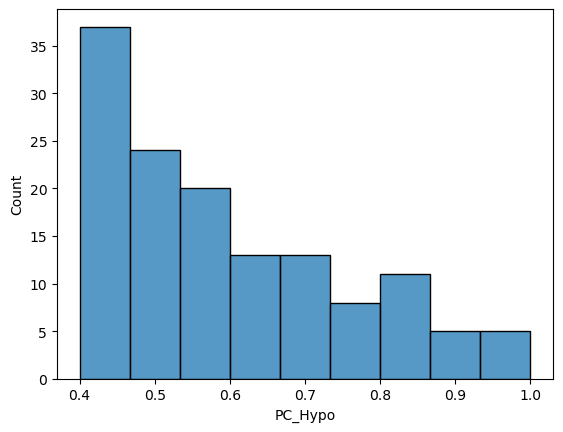

In [130]:
sns.histplot(c11_hypo['PC_Hypo'])

In [ ]:
# todo: maybe train a model to assign weights based on correlation scores, e.g. strongly negative, weakly negative, etc. 